In [ ]:
# 1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


### 2. Cargar datos

In [ ]:

df = pd.read_csv(r'C:\americo\ia_dema\12_Machine Learning\03_Clusterización\Ejercicio\order_2 (1).csv', parse_dates=['created_at', 'updated_at'])

#

### 3. Ingeniería de variables

    - 3.1 Extraer tiempo

In [ ]:
df['hour'] = df['created_at'].dt.hour
df['weekday'] = df['created_at'].dt.weekday
df['month'] = df['created_at'].dt.month


    - 3.2 Codificar product_id usando OneHotEncoder con sparse_output=False

In [ ]:

ohe = OneHotEncoder(sparse_output=False, drop='first')
prod_ohe = ohe.fit_transform(df[['product_id']])
prod_cols = ohe.get_feature_names_out(['product_id'])
df_ohe = pd.DataFrame(prod_ohe, columns=prod_cols, index=df.index)


    - 3.3 Concatenar y definir features/target

In [ ]:
df = pd.concat([df, df_ohe], axis=1)

# Toma TODAS las columnas predictorias en X
X = df.drop(columns=['id', 'order_id', 'product_id', 'total', 'created_at', 'updated_at'])
y = df['total']

# Opcional: verifica que X.columns.size == model.feature_importances_.size tras el fit
print("Num. features:", X.shape[1])


    - 4. División train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 5. Entrenamiento de modelos

    - 5.1 Regresión Lineal

In [47]:
lr = LinearRegression()


In [48]:
lr.fit(X_train, y_train)


LinearRegression()

In [49]:
y_pred_lr = lr.predict(X_test)

    - 5.2 Árbol de Regresión

In [50]:
tree = DecisionTreeRegressor(max_depth=5, random_state=42)


In [51]:
tree.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

In [52]:
y_pred_tree = tree.predict(X_test)

    - 6. Evaluación de desempeño

In [53]:
def eval_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name} → RMSE: {rmse:.2f}, R²: {r2:.3f}")


In [54]:

eval_model("Regresión Lineal", y_test, y_pred_lr)


Regresión Lineal → RMSE: 17.79, R²: 0.774


In [55]:
eval_model("Árbol de Regresión",   y_test, y_pred_tree)

Árbol de Regresión → RMSE: 20.96, R²: 0.686


### 7. Visualizaciones

In [56]:
plt.figure(figsize=(14,5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

    - 7.1 Scatter: cantidad vs total por producto

Text(0.5, 1.0, 'Cantidad vs Total por Producto')

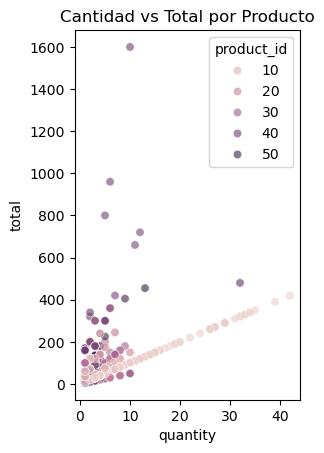

In [57]:

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='quantity', y='total', hue='product_id', alpha=0.6)
plt.title('Cantidad vs Total por Producto')

    - 7.2 Real vs Predicho (ambos modelos)

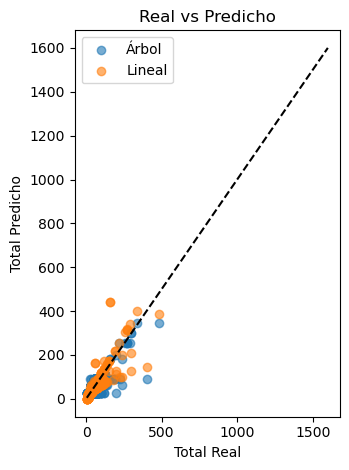

In [58]:

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_tree, alpha=0.6, label='Árbol')
plt.scatter(y_test, y_pred_lr,  alpha=0.6, label='Lineal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.xlabel('Total Real')
plt.ylabel('Total Predicho')
plt.legend()
plt.title('Real vs Predicho')
plt.tight_layout()
plt.show()


    - 7.3 Importancia de variables (modelo árbol)

C:\Users\Dell\AppData\Local\Temp\ipykernel_14888\3264435943.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, palette="viridis")


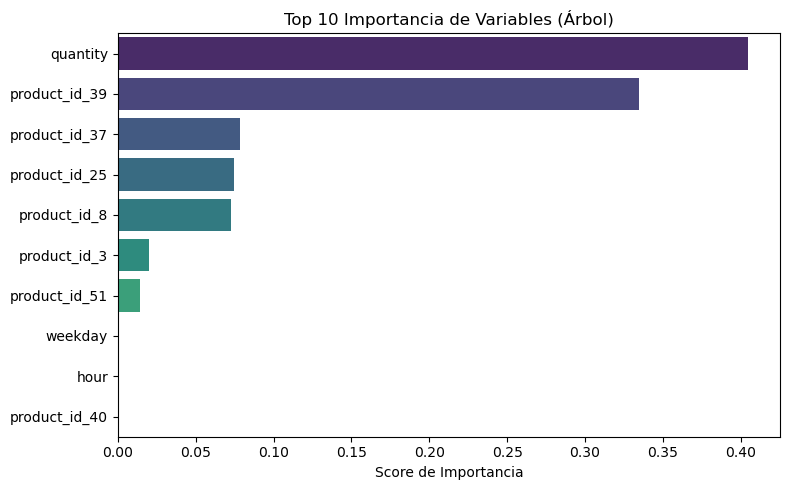

In [59]:
# Tras entrenar el árbol:
importances = pd.Series(tree.feature_importances_, index=X.columns)

# Ordena de mayor a menor y toma las 10 primeras
top_n = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_n.values, y=top_n.index, palette="viridis")
plt.title("Top 10 Importancia de Variables (Árbol)")
plt.xlabel("Score de Importancia")
plt.ylabel("")
plt.tight_layout()
plt.show()

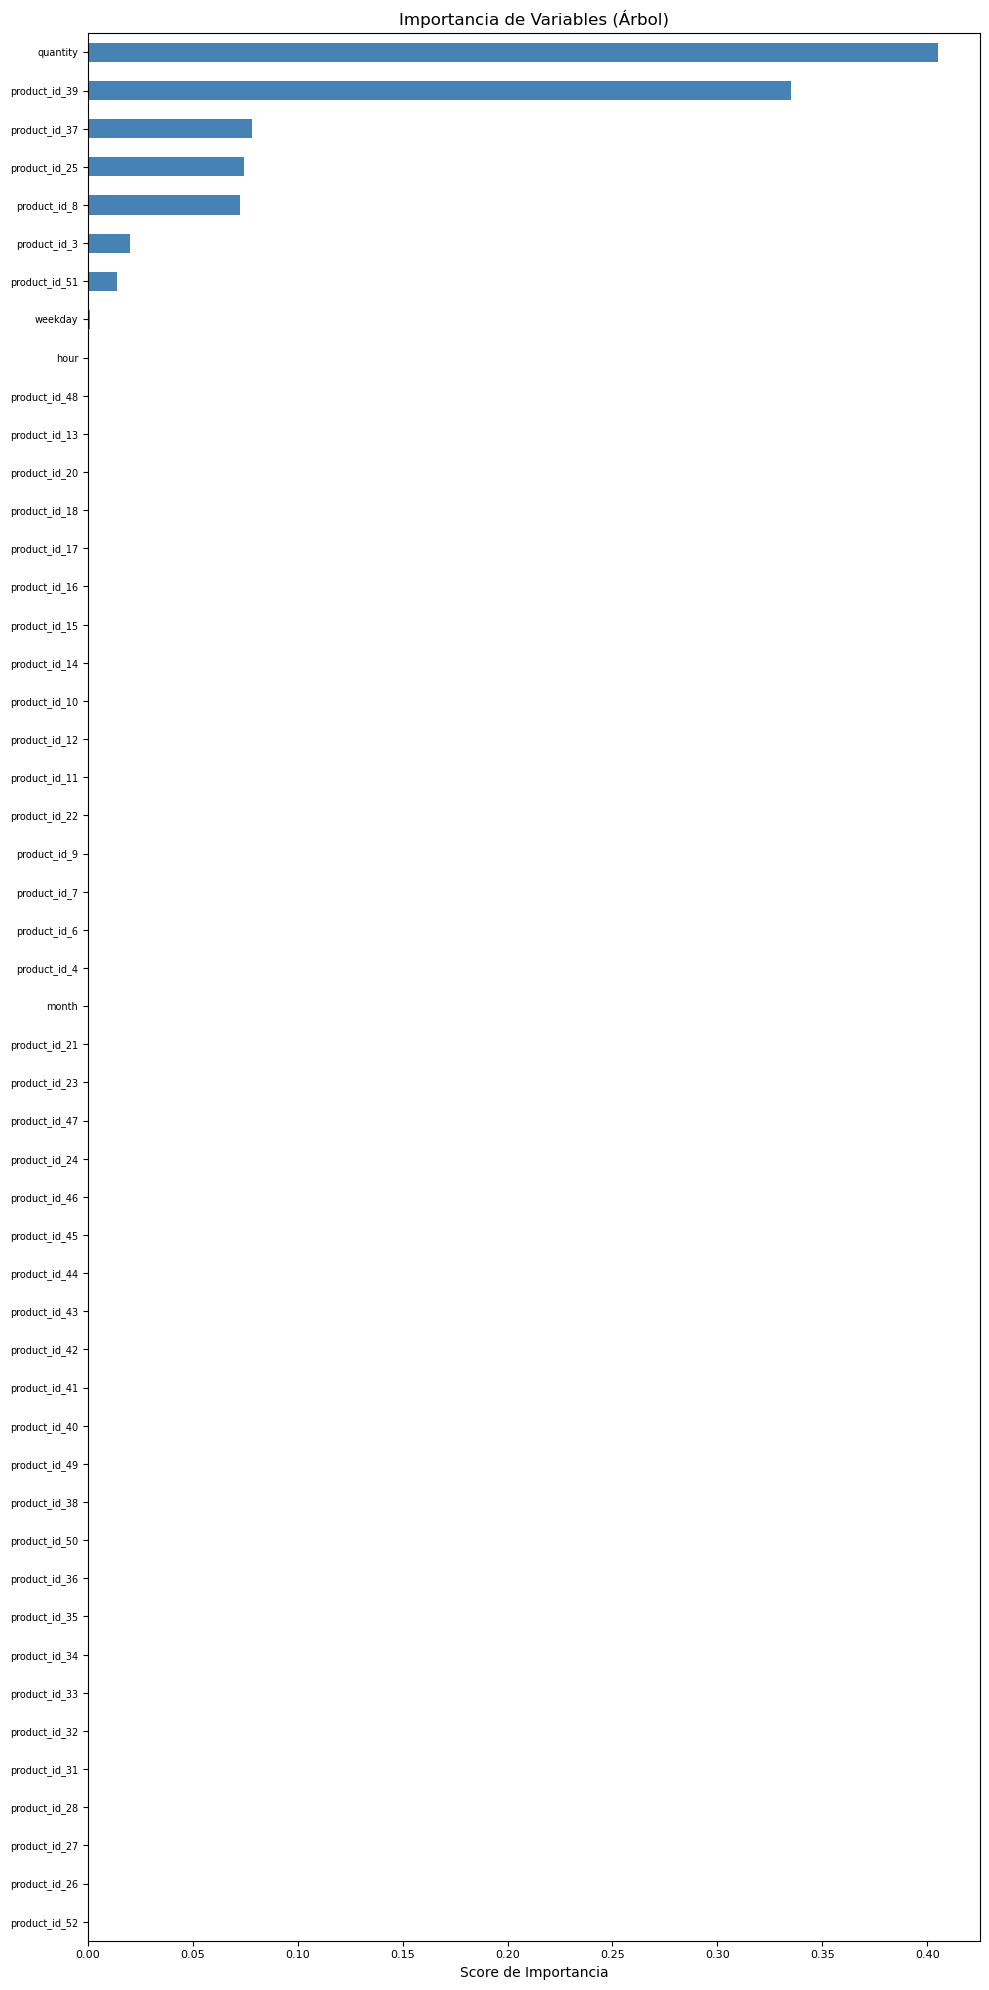

In [60]:
importances = pd.Series(tree.feature_importances_, index=X.columns)
importances = importances.sort_values()  # de menor a mayor

plt.figure(figsize=(10, 20))               # más alto para tantas barras
importances.plot.barh(color="steelblue")
plt.title("Importancia de Variables (Árbol)")
plt.xlabel("Score de Importancia")
plt.ylabel("")
plt.xticks(fontsize=8)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()


Shape del dataset: (7383, 7)
id                     int64
order_id               int64
product_id             int64
quantity               int64
total                  int64
updated_at    datetime64[ns]
created_at    datetime64[ns]
dtype: object
   id  order_id  product_id  quantity  total          updated_at  \
0  15        10           2         1     15 2025-04-21 13:56:11   
1  16        10           3         2     20 2025-04-21 13:56:11   
2  17        11           2         2     30 2025-04-21 13:57:34   
3  18        11           3         2     20 2025-04-21 13:57:34   
4  19        12           2         2     30 2025-04-21 13:58:15   

           created_at  
0 2025-04-21 13:56:11  
1 2025-04-21 13:56:11  
2 2025-04-21 13:57:34  
3 2025-04-21 13:57:34  
4 2025-04-21 13:58:15   

Descriptivas numéricas:
                 id     order_id   product_id     quantity        total  \
count  7383.000000  7383.000000  7383.000000  7383.000000  7383.000000   
mean   3714.249086  1635.1

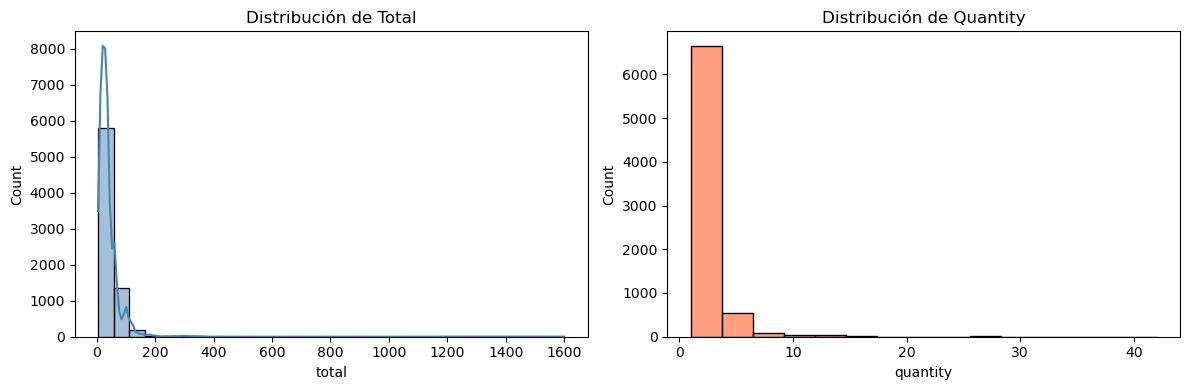

C:\Users\Dell\AppData\Local\Temp\ipykernel_14888\989160720.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='product_id', y='total', data=df, palette='Set2')


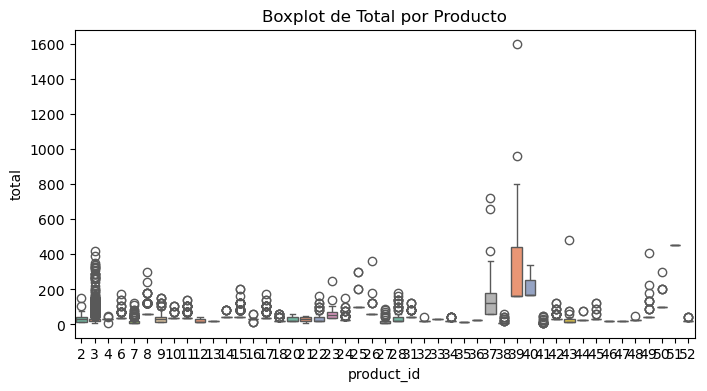

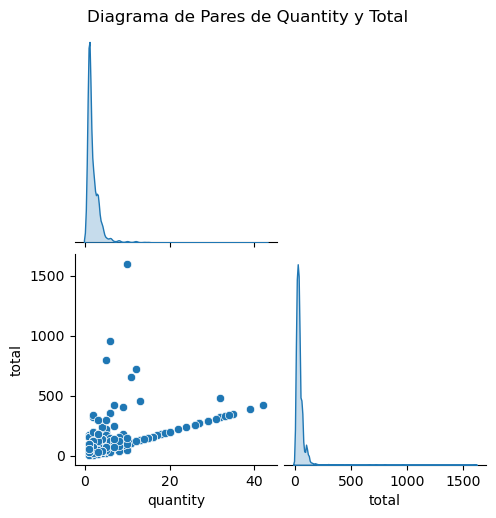

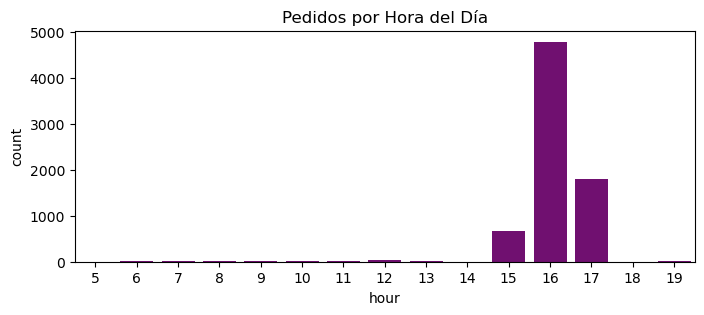

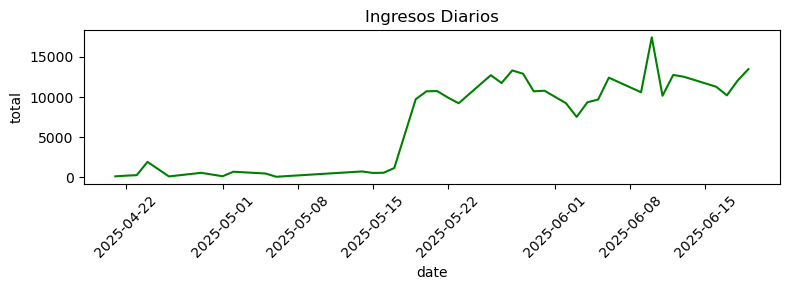

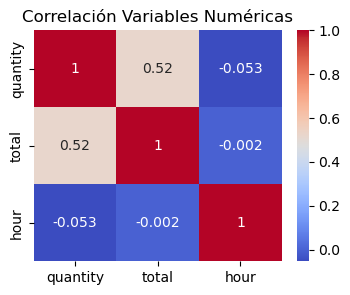

Número de features: 50 

Regresión Lineal → RMSE: 17.79, R²: 0.774
Árbol de Regresión → RMSE: 20.96, R²: 0.686


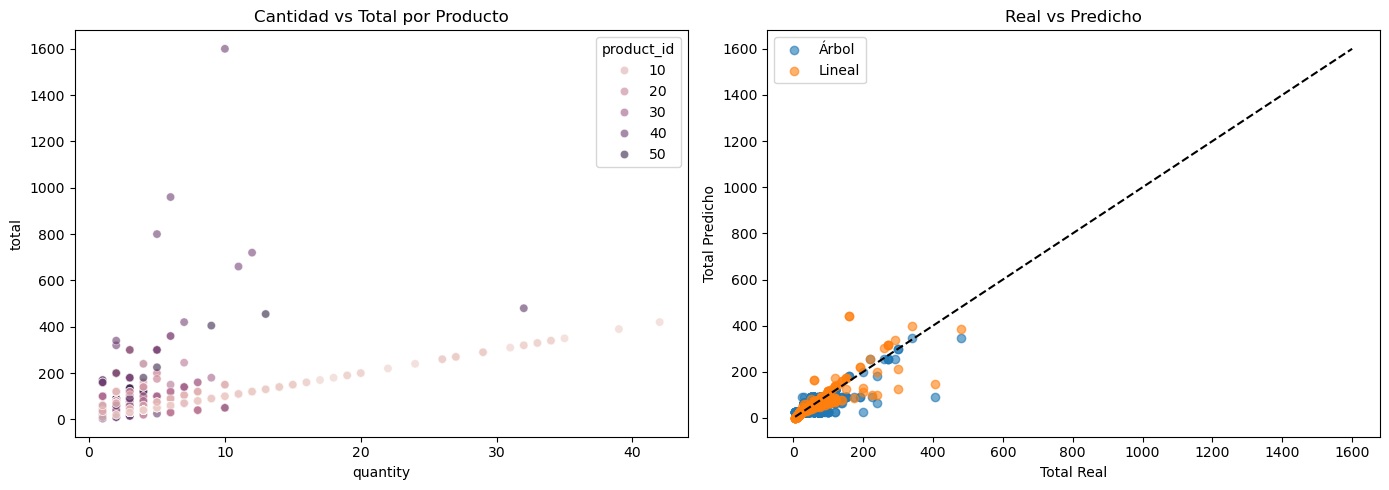

C:\Users\Dell\AppData\Local\Temp\ipykernel_14888\989160720.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='viridis')


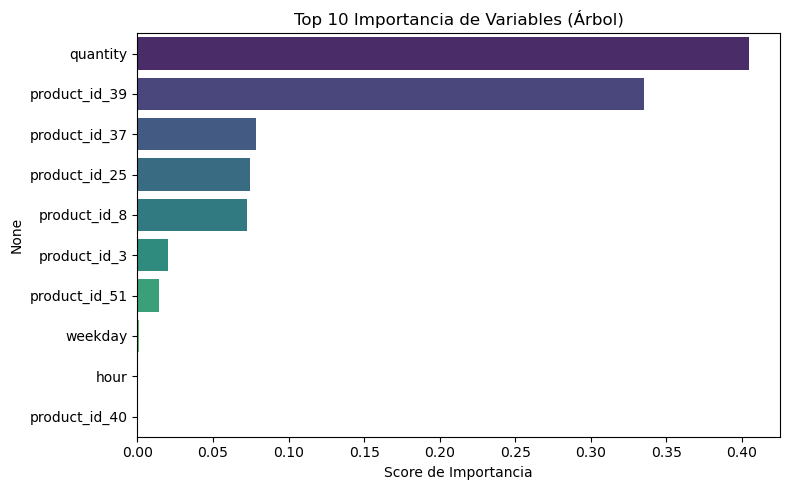

In [61]:
# 1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 2. Cargar datos
df = pd.read_csv(
    r'C:\americo\ia_dema\12_Machine Learning\03_Clusterización\Ejercicio\order_2 (1).csv',
    parse_dates=['created_at', 'updated_at']
)

# =====================================================
# 3. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# =====================================================

# 3.1 Forma, tipos y primeros registros
print("Shape del dataset:", df.shape)
print(df.dtypes)
print(df.head(), "\n")

# 3.2 Estadísticas descriptivas y conteos
print("Descriptivas numéricas:\n", df.describe(), "\n")
print("Conteo por product_id:\n", df['product_id'].value_counts(), "\n")

# 3.3 Valores faltantes y duplicados
print("Valores faltantes:\n", df.isna().sum(), "\n")
print("Registros duplicados:", df.duplicated().sum(), "\n")

# 3.4 Histogramas de 'total' y 'quantity'
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['total'], bins=30, kde=True, color='steelblue')
plt.title('Distribución de Total')

plt.subplot(1,2,2)
sns.histplot(df['quantity'], bins=15, kde=False, color='coral')
plt.title('Distribución de Quantity')
plt.tight_layout()
plt.show()

# 3.5 Boxplot de total por producto
plt.figure(figsize=(8,4))
sns.boxplot(x='product_id', y='total', data=df, palette='Set2')
plt.title('Boxplot de Total por Producto')
plt.show()

# 3.6 Diagrama de pares (pairplot) de variables numéricas
pair_vars = ['quantity', 'total']
# si quieres incluir también hour, weekday, month, descomenta la línea siguiente
# pair_vars = ['quantity','total','hour_temp','weekday_temp','month_temp']
sns.pairplot(df[pair_vars], diag_kind='kde', corner=True)
plt.suptitle('Diagrama de Pares de Quantity y Total', y=1.02)
plt.show()

# 3.7 Volumen de pedidos por hora
df['hour'] = df['created_at'].dt.hour
plt.figure(figsize=(8,3))
sns.countplot(x='hour', data=df, color='purple')
plt.title('Pedidos por Hora del Día')
plt.show()

# 3.8 Ingresos diarios
df['date'] = df['created_at'].dt.date
daily_revenue = df.groupby('date')['total'].sum().reset_index()
plt.figure(figsize=(8,3))
sns.lineplot(x='date', y='total', data=daily_revenue, color='green')
plt.title('Ingresos Diarios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3.9 Matriz de correlación
num_cols = ['quantity', 'total', 'hour']
corr = df[num_cols].corr()
plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación Variables Numéricas')
plt.show()

# =====================================================
# 4. INGENIERÍA DE VARIABLES y MODELADO
# =====================================================

# 4.1 Extraer más componentes temporales
df['weekday'] = df['created_at'].dt.weekday
df['month']   = df['created_at'].dt.month

# 4.2 One-hot encoding de product_id
ohe = OneHotEncoder(sparse_output=False, drop='first')
prod_ohe = ohe.fit_transform(df[['product_id']])
prod_cols = ohe.get_feature_names_out(['product_id'])
df_ohe = pd.DataFrame(prod_ohe, columns=prod_cols, index=df.index)

# 4.3 Concatenar y preparar X, y dinámicamente
df = pd.concat([df, df_ohe], axis=1)
exclude = ['id', 'order_id', 'product_id', 'total',
           'created_at', 'updated_at', 'date']
X = df.drop(columns=exclude)
y = df['total']

print("Número de features:", X.shape[1], "\n")

# 5. División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Entrenamiento de modelos
lr = LinearRegression().fit(X_train, y_train)
tree = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)

y_pred_lr   = lr.predict(X_test)
y_pred_tree = tree.predict(X_test)

# 7. Evaluación de desempeño
def eval_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name} → RMSE: {rmse:.2f}, R²: {r2:.3f}")

eval_model("Regresión Lineal", y_test, y_pred_lr)
eval_model("Árbol de Regresión", y_test, y_pred_tree)

# =====================================================
# 8. VISUALIZACIONES FINALES
# =====================================================

plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='quantity', y='total',
                hue='product_id', alpha=0.6)
plt.title('Cantidad vs Total por Producto')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_tree, alpha=0.6, label='Árbol')
plt.scatter(y_test, y_pred_lr,  alpha=0.6, label='Lineal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.xlabel('Total Real')
plt.ylabel('Total Predicho')
plt.legend()
plt.title('Real vs Predicho')
plt.tight_layout()
plt.show()

# 8.3 Importancia de variables (modelo árbol) — Top 10
importances = pd.Series(tree.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top10.values, y=top10.index, palette='viridis')
plt.title('Top 10 Importancia de Variables (Árbol)')
plt.xlabel('Score de Importancia')
plt.tight_layout()
plt.show()
